# Chapter6 The Method of Godunov for Non–linear Systems

### The Riemann Problem for the Euler Equations

오일러 방정식은 3가지의 보존법칙을 의미함.
1. 질량 보존 법칙.
2. 운동량 보존 법칙.
3. 에너지 보존 법칙.

위의 보존 법칙을 하나의 시스템 수식으로 표현하면 

<img src="images/image copy 3.png" width="600">

이때 F(U)x = dF(U)/dx = dF(U)/dU * dU/dx이므로

<img src="images/image copy 4.png" width="600">
<img src="images/image copy 6.png" width="600">

여기서 A의 eigen value와 vector를 구하면 

<img src="images/image copy 5.png" width="600">

다음과 같음.
너무 복잡해서 다음에 깔끔하게 정리하겠음.

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from chapter6 import *
from CFD import U_to_W, W_to_U

In [3]:
#Constant parameters
NUM_CELLS = 100

X_DOMAIN = [0, 1]
T_DOMAIN = [0, 0.15]
DX = (X_DOMAIN[1] - X_DOMAIN[0]) / NUM_CELLS
CFL_COEFFICIENT = 0.8
GAMMA = 1.4
X0 = 0.5
TOL = 1e-6

### the conservative formula
$$u^{n+1}_i = u^n_i + \frac{\Delta t}{\Delta x}\left(f_{i-\frac{1}{2}} - f_{i+\frac{1}{2}}\right)$$

In general, one expresses the Godunov intercell numerical flux as
$$f^{\text{god}}_{i+\frac{1}{2}} = f\left(u_{i+\frac{1}{2}}(0)\right)$$


### dt calculation to satisfy CFL coefficient.

(speed of characteristic) / (speed of cell) <= CFL_COEFFICIENT

--> MAX(|u|) / (DX / DT) = CFL_COEFFICIENT

CFL_COEFFICIENT * (DX / DT) = MAX(u)

DT = CFL_COEFFICIENT * DX / MAX(u)

MAX(u) = max(|u| + a)

<img src="images/image copy 7.png" width="600">


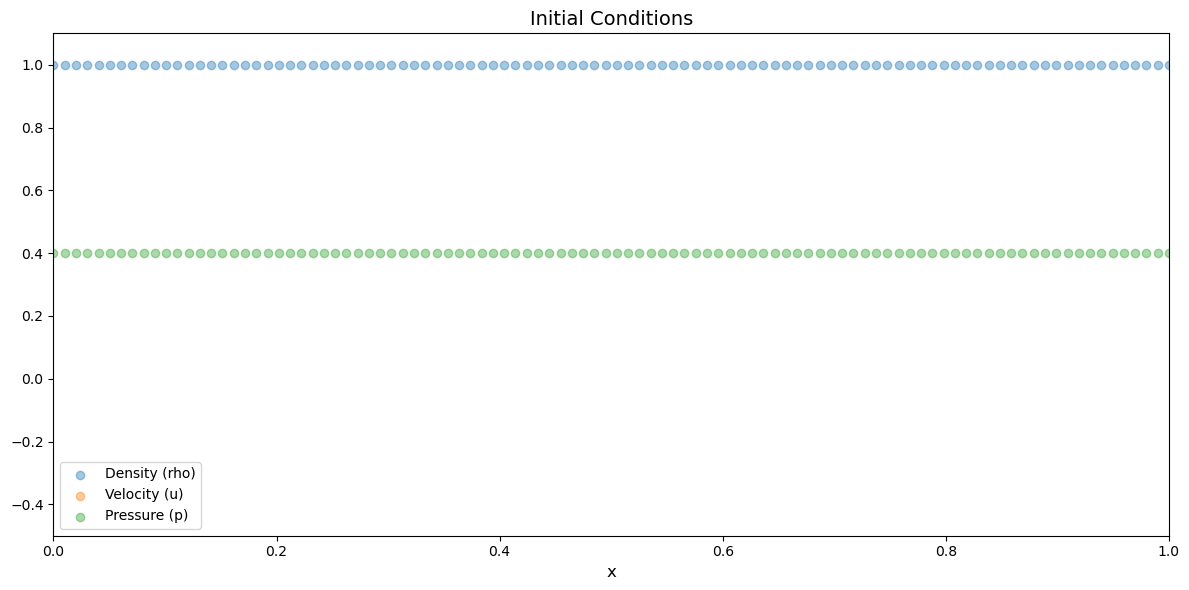

In [4]:
#Initial conditions
# +2 for cell boundary
# 0 for density, 1 for velocity, 2 for pressure
CELL = torch.zeros((1, 1,NUM_CELLS, 5))

border = int(X_DOMAIN[0] + X0 / DX) + 1
#left state
CELL[..., :border, 0] = 1.0
CELL[..., :border, 1] = -2.0
CELL[..., :border, 4] = 0.4
#right state
CELL[..., border:, 0] = 1
CELL[..., border:, 1] = 2.0
CELL[..., border:, 4] = 0.4

#Plot initial conditions as 1D colored points
rho_values = CELL[..., 0].numpy()
u_values = CELL[..., 1].numpy()
p_values = CELL[..., 4].numpy()

x = np.linspace(X_DOMAIN[0], X_DOMAIN[1], NUM_CELLS)

fig, ax = plt.subplots(figsize=(12, 6))
scatter1 = ax.scatter(x, rho_values, label='Density (rho)', alpha=0.4)
scatter2 = ax.scatter(x, u_values, label='Velocity (u)', alpha=0.4)
scatter3 = ax.scatter(x, p_values, label='Pressure (p)', alpha=0.4)
ax.set_xlim(X_DOMAIN[0], X_DOMAIN[1])
ax.set_ylim(-0.5, 1.1)
ax.set_xlabel('x', fontsize=12)
ax.set_title('Initial Conditions', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
def update(CELL, cfl_coefficient, dx, GAMMA):
    """
    CELL: (1, 1, Nx, 5) - [rho, u, v, w, p] primitive variables (with ghost cells)
    """
    # Riemann solver로 cell interface에서 primitive variables 얻기
    dt = cal_dt(CELL, cfl_coefficient, dx, GAMMA)
    flux = exact_riemann_flux(CELL[:, :, :-1, :], CELL[:, :, 1:, :], GAMMA)
    
    U_cell = W_to_U(CELL[:, :, 1:-1, :], GAMMA)
    
    U_new = U_cell + dt/dx * (flux[:, :, :-1, :] - flux[:, :, 1:, :])
    
    # Convert back to primitive
    CELL[:, :, 1:-1, :] = U_to_W(U_new, GAMMA)
    
    CELL = apply_boundary_condition(CELL, normal='x')

    return CELL, dt

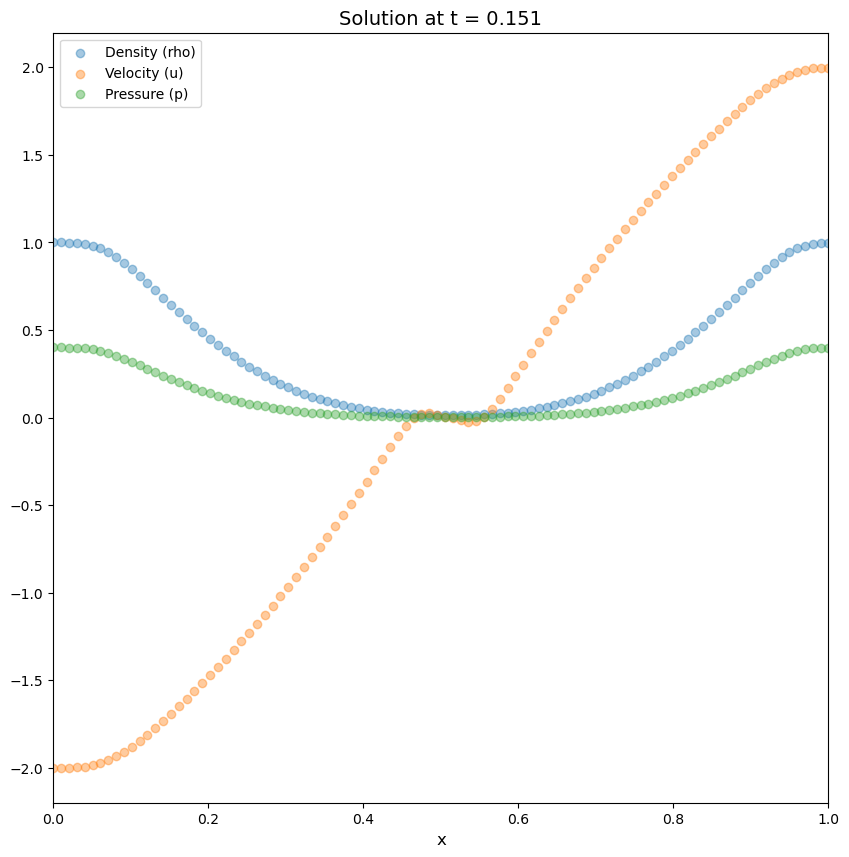

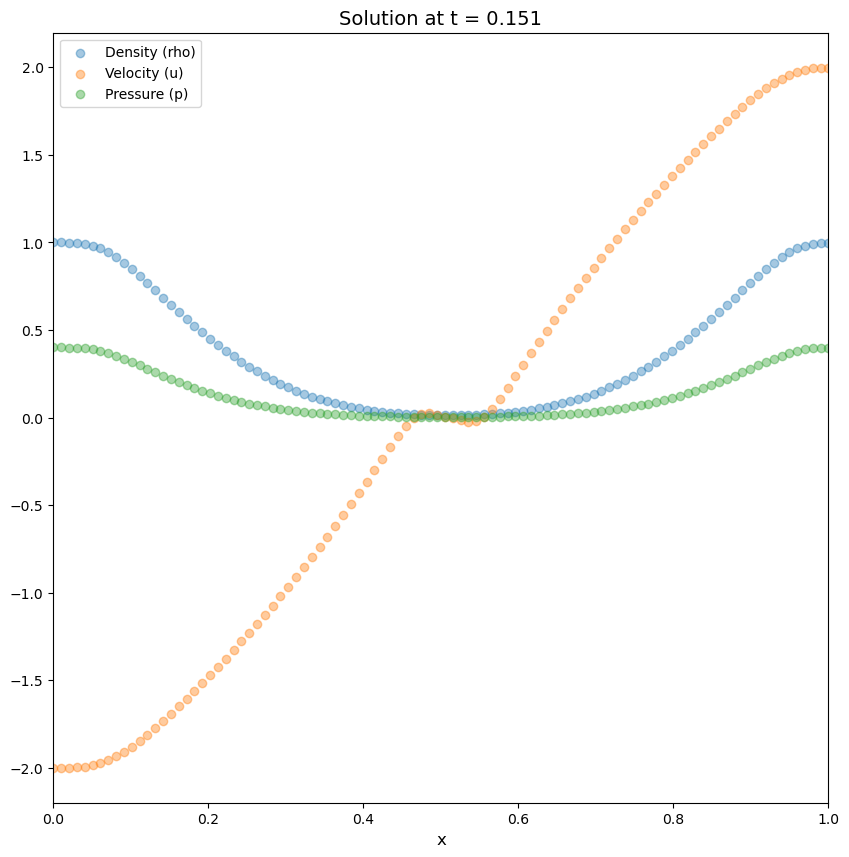

In [6]:
# Setup figure and axis
fig, ax = plt.subplots(figsize=(10, 10))
x = np.linspace(X_DOMAIN[0], X_DOMAIN[1], NUM_CELLS)

# Initial plot
rho_values = CELL[..., 0].numpy()
u_values = CELL[..., 1].numpy()
p_values = CELL[..., 4].numpy()

ax.scatter(x, rho_values, label='Density (rho)', alpha=0.4)
ax.scatter(x, u_values, label='Velocity (u)', alpha=0.4)
ax.scatter(x, p_values, label='Pressure (p)', alpha=0.4)
ax.set_xlim(X_DOMAIN[0], X_DOMAIN[1])
ax.set_ylim(-0.5, 1.1)
ax.set_xlabel('x', fontsize=12)
ax.legend()

# Animation parameters
t = T_DOMAIN[0]

# Animation function
while t < T_DOMAIN[1]:
    CELL, dt = update(CELL, CFL_COEFFICIENT, DX, GAMMA)
    t = t + dt

    # Clear previous frame
    ax.cla()

    # Redraw scatter plot
    rho_values = CELL[..., 0].numpy()
    u_values = CELL[..., 1].numpy()
    p_values = CELL[..., 4].numpy()
    ax.scatter(x, rho_values, label='Density (rho)', alpha=0.4)
    ax.scatter(x, u_values, label='Velocity (u)', alpha=0.4)
    ax.scatter(x, p_values, label='Pressure (p)', alpha=0.4)

    # Restore axes settings
    ax.set_xlim(X_DOMAIN[0], X_DOMAIN[1])
    #ax.set_ylim(-0.5, 1.1)
    ax.set_xlabel('x', fontsize=12)
    ax.legend()

    # Update title
    ax.set_title(f'Solution at t = {t:.3f}', fontsize=14)
    clear_output(wait=True)
    display(fig)
    